<a href="https://colab.research.google.com/github/OMDATTA/student_performance_prediction/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scikit-learn pandas

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
data = {
    'review': [
        "The product quality is excellent.",
        "Terrible experience, waste of money.",
        "Average performance, nothing special.",
        "I love this! Highly recommend.",
        "Worst purchase ever, very disappointed."
    ],
    'sentiment': ["Positive", "Negative", "Neutral", "Positive", "Negative"]
}

df = pd.DataFrame(data)
df.head()


,review,sentiment
0,The product quality is excellent.,Positive
1,"Terrible experience, waste of money.",Negative
2,"Average performance, nothing special.",Neutral
3,I love this! Highly recommend.,Positive
4,"Worst purchase ever, very disappointed.",Negative


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [5]:
log_reg = LogisticRegression()
log_reg.fit(X_train_tfidf, y_train)
y_pred_log = log_reg.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Logistic Regression Accuracy: 0.0
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       1.0
    Positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Naive Bayes Accuracy: 0.0
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       1.0
    Positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

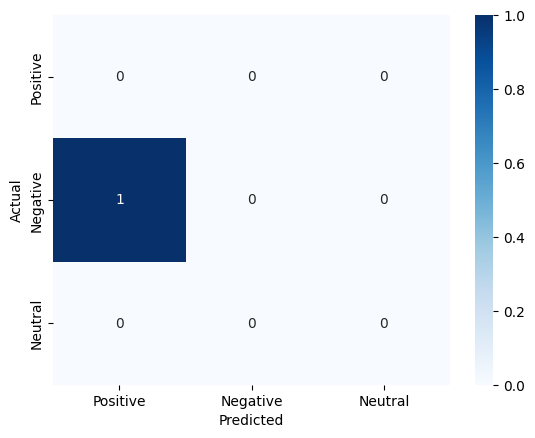

In [6]:
cm = confusion_matrix(y_test, y_pred_log, labels=["Positive","Negative","Neutral"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Positive","Negative","Neutral"], yticklabels=["Positive","Negative","Neutral"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [7]:
sample_review = ["The product quality is excellent."]
sample_tfidf = vectorizer.transform(sample_review)
print("Prediction (Logistic Regression):", log_reg.predict(sample_tfidf)[0])
print("Prediction (Naive Bayes):", nb.predict(sample_tfidf)[0])


Prediction (Logistic Regression): Positive
Prediction (Naive Bayes): Positive
